In [53]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

In [54]:
# Сплайн Акимы
def get_akima_coeffs(x, y):
    n = len(x)
    if n < 2:
        return None
    
    m = [(y[i+1]-y[i])/(x[i+1]-x[i]) if x[i+1]-x[i] != 0 else 0 for i in range(n-1)]
    
    s = [0]*n
    if n >= 2:
        s[0] = m[0]
        s[-1] = m[-1]
    
    if n >= 3:
        s[1] = (m[0]+m[1])/2
        s[-2] = (m[-2]+m[-1])/2
    
    for i in range(2, n-2):
        w1, w2 = abs(m[i]-m[i-1]), abs(m[i-1]-m[i-2])
        if w1+w2 > 1e-10:
            s[i] = (w1*m[i-1] + w2*m[i])/(w1+w2)
        else:
            s[i] = (m[i-1]+m[i])/2
    
    coeffs = []
    for i in range(n-1):
        dx = x[i+1]-x[i]
        if dx == 0:
            continue
        a = y[i]
        b = s[i]
        c = (3*m[i] - 2*s[i] - s[i+1])/dx
        d = (s[i] + s[i+1] - 2*m[i])/(dx*dx)
        coeffs.append((x[i], x[i+1], a, b, c, d))
    return coeffs

# Вычисление сплайна Акимы в точке
def akima_val(coeffs, x_val):
    if coeffs is None:
        return np.nan
    for xl, xr, a, b, c, d in coeffs:
        if xl <= x_val <= xr:
            dx = x_val - xl
            return a + b*dx + c*dx**2 + d*dx**3
    return np.nan

def akima_surface_2d(x_points, y_points, z_grid, x_new, y_new):
    
    # интерполяция по X
    Zx = np.zeros((len(y_points), len(x_new)))

    for j in range(len(y_points)):
        coeffs = get_akima_coeffs(x_points, z_grid[j, :])
        for i, xv in enumerate(x_new):
            Zx[j, i] = akima_val(coeffs, xv)

    # интерполяция по Y
    Zxy = np.zeros((len(y_new), len(x_new)))

    for i in range(len(x_new)):
        coeffs = get_akima_coeffs(y_points, Zx[:, i])
        for j, yv in enumerate(y_new):
            Zxy[j, i] = akima_val(coeffs, yv)

    return Zxy

In [58]:
# Загружаем данные
Z_raw = np.load("./data/fuji_elevation.npy").astype(np.float64)
lat = np.load("./data/fuji_lat.npy")
lon = np.load("./data/fuji_lon.npy")

# Переворачиваем
Z_raw = Z_raw[::-1, :]
lat_sn = lat[::-1]


Опорные точки: 135 x 135 = 18225

Интерполяция на сетку 500 x 500...
  Готово! Высота: 64 - 3747 м


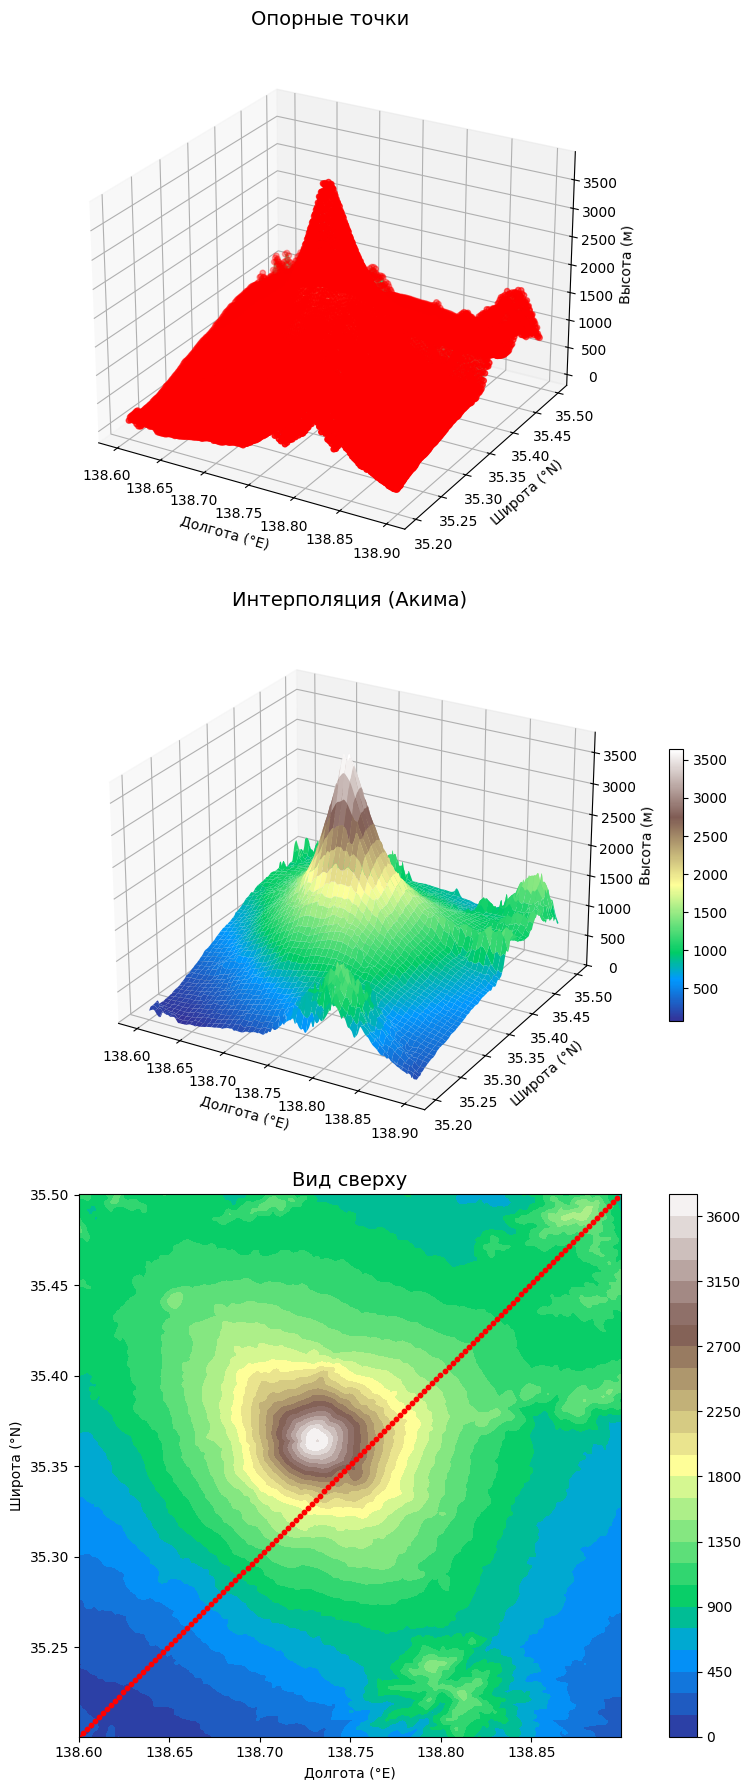

In [68]:
# Используем градусы
use_meters = False

if use_meters:
    lat0 = 35.3606
    deg2m_lat = 111_320.0
    deg2m_lon = 111_320.0 * np.cos(np.radians(lat0))
    X_coords = (lon - lon[0]) * deg2m_lon
    Y_coords = (lat_sn - lat_sn[0]) * deg2m_lat
    x_label = 'Восток (км)'
    y_label = 'Север (км)'
    X_display = X_coords / 1000
    Y_display = Y_coords / 1000
else:
    X_coords = lon
    Y_coords = lat_sn
    x_label = 'Долгота (°E)'
    y_label = 'Широта (°N)'
    X_display = X_coords
    Y_display = Y_coords

step_points = 8  # Опорные точки (берем каждую iю точку)
resolution = 500  # Гладкость графика

X_pts = X_coords[::step_points]
Y_pts = Y_coords[::step_points]
Z_pts = Z_raw[::step_points, ::step_points]

print(f"\nОпорные точки: {Z_pts.shape[0]} x {Z_pts.shape[1]} = {Z_pts.shape[0] * Z_pts.shape[1]}")

X_smooth = np.linspace(X_pts.min(), X_pts.max(), resolution)
Y_smooth = np.linspace(Y_pts.min(), Y_pts.max(), resolution)

print(f"\nИнтерполяция на сетку {resolution} x {resolution}...")
Z_smooth = akima_surface_2d(X_pts, Y_pts, Z_pts, X_smooth, Y_smooth)
print(f"  Готово! Высота: {np.nanmin(Z_smooth):.0f} - {np.nanmax(Z_smooth):.0f} м")

# Визуализация
fig = plt.figure(figsize=(10, 18))

# Опорные точки
ax1 = fig.add_subplot(311, projection='3d')

X_display_pts, Y_display_pts = np.meshgrid(
    X_display[::step_points],
    Y_display[::step_points]
)

X_display_grid, Y_display_grid = np.meshgrid(
    np.linspace(X_display.min(), X_display.max(), resolution),
    np.linspace(Y_display.min(), Y_display.max(), resolution)
)

ax1.plot_surface(X_display_pts, Y_display_pts, Z_pts, cmap='terrain', alpha=0.6)

ax1.scatter(X_display_pts, Y_display_pts, Z_pts, c='red', s=15)

ax1.set_title('Опорные точки', fontsize=14)
ax1.set_xlabel(x_label)
ax1.set_ylabel(y_label)
ax1.set_zlabel('Высота (м)')
ax1.view_init(25, -60)

# Интерполяция
ax2 = fig.add_subplot(312, projection='3d')
surf = ax2.plot_surface(X_display_grid, Y_display_grid, Z_smooth, cmap='terrain',linewidth=0)

ax2.set_title('Интерполяция (Акима)', fontsize=14)
ax2.set_xlabel(x_label)
ax2.set_ylabel(y_label)
ax2.set_zlabel('Высота (м)')
ax2.view_init(25, -60)

fig.colorbar(surf, ax=ax2, shrink=0.5)

# Вид сверху
ax3 = fig.add_subplot(313)
contour = ax3.contourf(X_display_grid, Y_display_grid, Z_smooth, levels=30, cmap='terrain')
ax3.scatter(X_display[::step_points], Y_display[::step_points], c='red', s=10)

ax3.set_title('Вид сверху', fontsize=14)
ax3.set_xlabel(x_label)
ax3.set_ylabel(y_label)
ax3.set_aspect('equal')

fig.colorbar(contour, ax=ax3)

plt.tight_layout()
plt.show()


ОЦЕНКА ОШИБКИ...
MAE  = 4.29 м
RMSE = 7.01 м
MAX  = 86.59 м


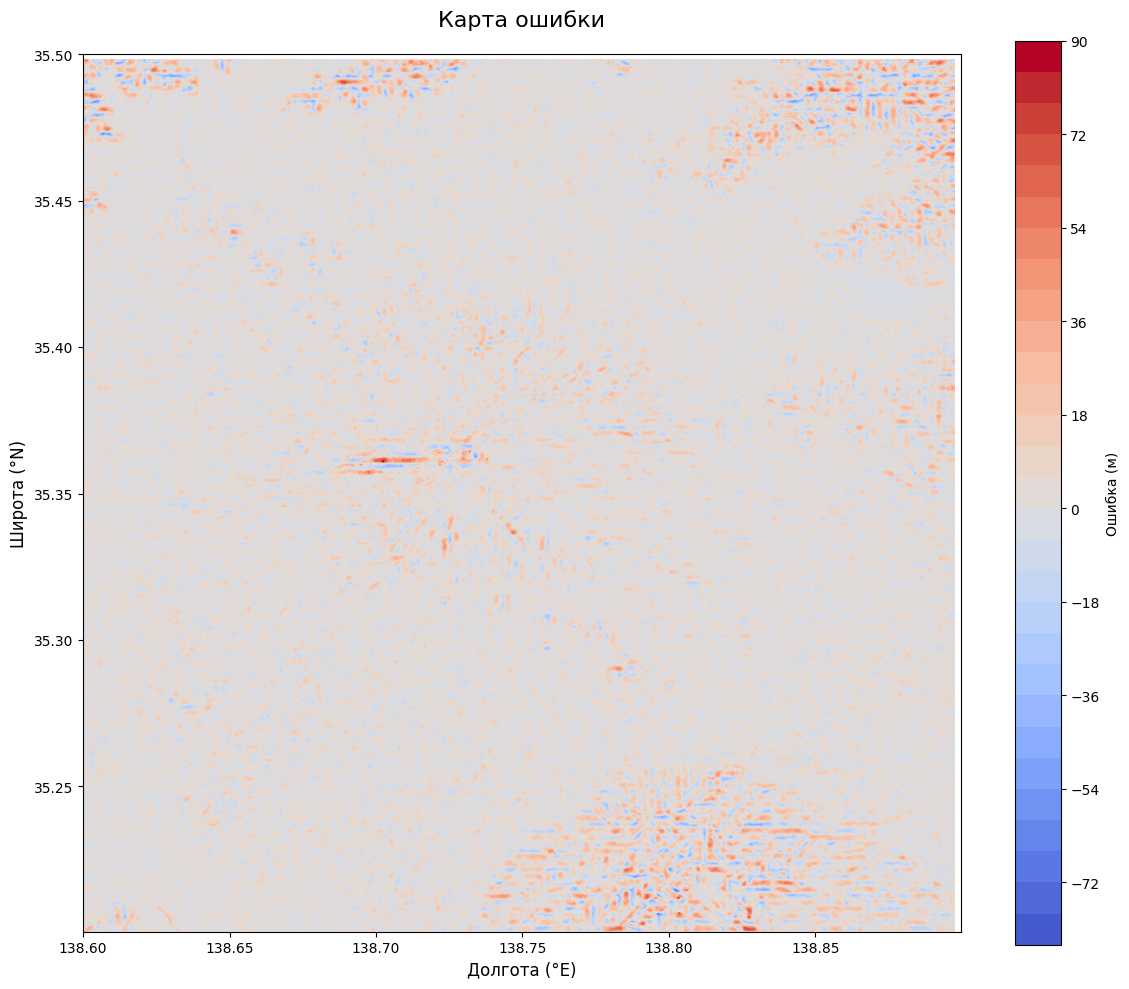

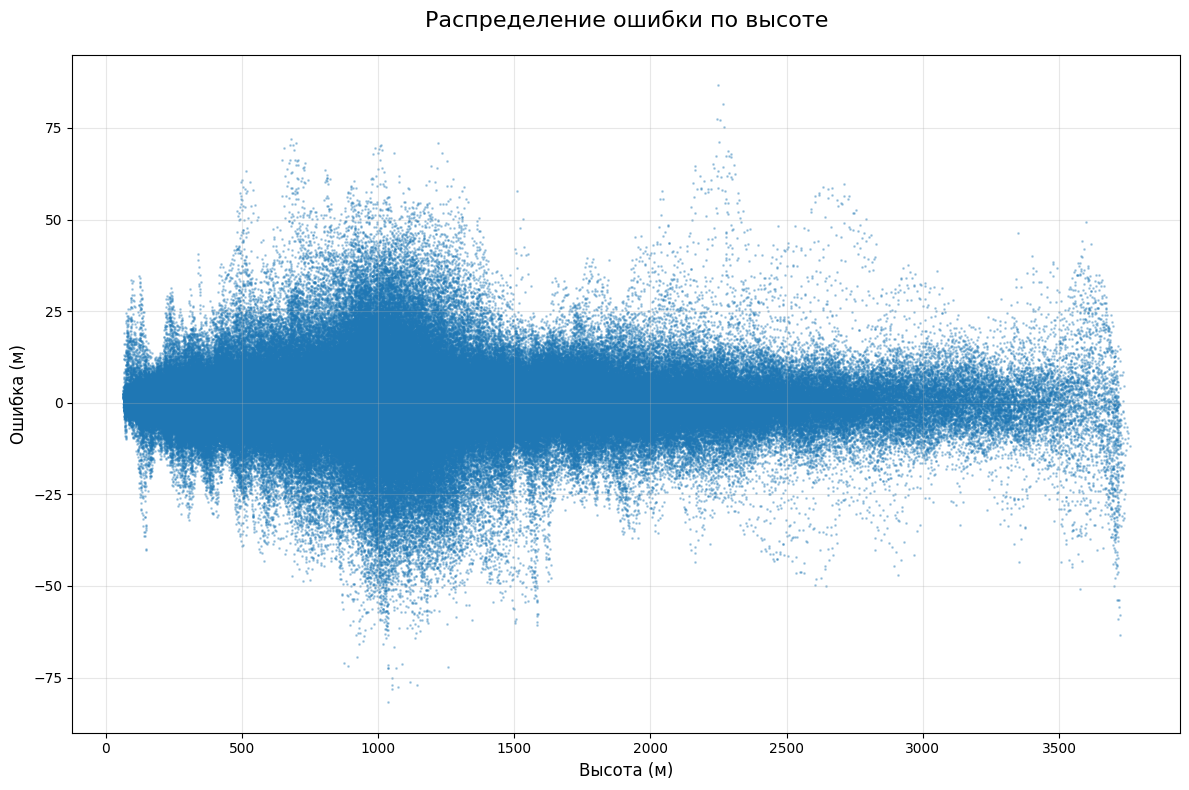

In [69]:
print("\nОЦЕНКА ОШИБКИ...")

Z_interp_on_raw = akima_surface_2d(
    X_smooth, Y_smooth, Z_smooth,
    X_coords, Y_coords
)

error = Z_interp_on_raw - Z_raw

mae = np.nanmean(np.abs(error))
rmse = np.sqrt(np.nanmean(error**2))
max_err = np.nanmax(np.abs(error))

# Вывод основных метрик
print(f"MAE  = {mae:.2f} м")
print(f"RMSE = {rmse:.2f} м")
print(f"MAX  = {max_err:.2f} м")

# Сетка
Xg, Yg = np.meshgrid(X_display, Y_display)

# симметричная шкала
v = np.nanmax(np.abs(error))

# Карта ошибки
plt.figure(figsize=(12, 10))

c = plt.contourf(Xg, Yg, error, levels=30, cmap='coolwarm', vmin=-v, vmax=v)

plt.title('Карта ошибки', fontsize=16, pad=20)
plt.xlabel(x_label, fontsize=12)
plt.ylabel(y_label, fontsize=12)
plt.gca().set_aspect('equal')

plt.colorbar(c, label='Ошибка (м)')

plt.tight_layout()
plt.show()

# Распределение ошибки по высоте
plt.figure(figsize=(12, 8))

plt.scatter(Z_raw.flatten(), error.flatten(), s=1, alpha=0.3)

plt.title('Распределение ошибки по высоте', fontsize=16, pad=20)
plt.xlabel('Высота (м)', fontsize=12)
plt.ylabel('Ошибка (м)', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()